# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [5]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings.parquet') LIMIT 5").df()

,SensorID_Coris,SensorReadingUTC,DeviceID_Coris,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,...,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
0,21373,1721174858,12162,69.570000,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,21373,1721175458,12162,69.669998,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,21373,1721176058,12162,69.660004,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,21373,1721176658,12162,69.660004,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,21373,1721177258,12162,69.669998,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [6]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings.parquet') LIMIT 5").df()

,DeviceID_Coris,DeviceName,SensorReadingUTC,SensorReadingF,SensorReadingRh
0,12162,Peabody TH-L Mammal Hall D444,1721174858,69.570000,49.340000
1,12162,Peabody TH-L Mammal Hall D444,1721175458,69.669998,49.549999
2,12162,Peabody TH-L Mammal Hall D444,1721176058,69.660004,49.369999
3,12162,Peabody TH-L Mammal Hall D444,1721176658,69.660004,49.340000
4,12162,Peabody TH-L Mammal Hall D444,1721177258,69.669998,49.630001


In [7]:
duckdb.sql("SELECT * FROM read_parquet('data/sensors.parquet') LIMIT 5").df()

,SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
0,23332,CSC,H101,Not Indicated,D032,RH CSC H101_D032,Humidity,12394,Collection Studies Center (West Campus)
1,23331,CSC,H101,Not Indicated,D032,Temp CSC H101_D032,Temperature,12394,Collection Studies Center (West Campus)
2,23330,CSC,K127,Not Indicated,0D0EA,RH CSC K127_0D0EA,Humidity,12395,Collection Studies Center (West Campus)
3,23329,CSC,K127,Not Indicated,0D0EA,Temp CSC K127_0D0EA,Temperature,12395,Collection Studies Center (West Campus)
4,23401,CSC,K160,Not Indicated,00cd90,RH CSC K160_00cd90,Humidity,12416,Collection Studies Center (West Campus)


In [8]:
duckdb.sql("SELECT * FROM read_parquet('data/devices.parquet') LIMIT 5").df()

,DeviceID,BuildingID,Room,CardinalDirection,DeviceName,DeviceID_Coris,Building
0,D032,CSC,H101,Not Indicated,Test 1 D032,12394,Collection Studies Center (West Campus)
1,0D0EA,CSC,K127,Not Indicated,Test 2 0D0EA,12395,Collection Studies Center (West Campus)
2,00cd90,CSC,K160,Not Indicated,L_0025CA0A0000CD90,12416,Collection Studies Center (West Campus)
3,00cd95,CSC,K215,Not Indicated,L_0025CA0A0000CD95,12421,Collection Studies Center (West Campus)
4,00cda7,CSC,K217,Not Indicated,L_0025CA0A0000CDA7,12425,Collection Studies Center (West Campus)


In [11]:
duckdb.sql("SELECT * FROM read_parquet('data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1700063665,2023-11-15 08:54:25,2023-11-15 01:54:25-07:00,2023-11-15,03:54:25,2023,11,Wednesday,3,3,3,AM
1,1718935710,2024-06-20 20:08:30,2024-06-20 14:08:30-06:00,2024-06-20,16:08:30,2024,6,Thursday,4,16,4,PM
2,1721174858,2024-07-16 18:07:38,2024-07-16 12:07:38-06:00,2024-07-16,14:07:38,2024,7,Tuesday,2,14,2,PM
3,1721175458,2024-07-16 18:17:38,2024-07-16 12:17:38-06:00,2024-07-16,14:17:38,2024,7,Tuesday,2,14,2,PM
4,1721176058,2024-07-16 18:27:38,2024-07-16 12:27:38-06:00,2024-07-16,14:27:38,2024,7,Tuesday,2,14,2,PM


In [12]:
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings_daily.parquet') LIMIT 5").df()

,date,SensorID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2023-11-15,25992,30,1275.000000,0.000000,42.500000,NaN,42.500000,NaN
1,2023-11-15,25993,30,0.000000,1539.000366,NaN,51.299999,NaN,51.299999
2,2024-06-20,26831,30,2072.999512,0.000000,69.099998,NaN,69.099998,NaN
3,2024-06-20,26832,30,0.000000,1410.000000,NaN,47.000000,NaN,47.000000
4,2024-07-16,21373,60,4195.000000,0.000000,69.150002,NaN,71.190002,NaN


In [13]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings_daily.parquet') LIMIT 5").df()

,date,DeviceID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2023-11-15,12943,900,38250.000000,46170.410156,42.500000,51.299999,42.500000,51.299999
1,2024-06-20,13394,900,62190.535156,42300.000000,69.099998,47.000000,69.099998,47.000000
2,2024-07-16,12162,60,4195.000000,3059.729248,69.150002,49.340000,71.190002,56.380001
3,2024-07-16,12165,60,4088.319580,3287.989258,67.870003,52.660000,68.580002,57.529999
4,2024-07-16,12167,60,4228.979004,3356.470215,70.410004,55.000000,70.540001,57.910000


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

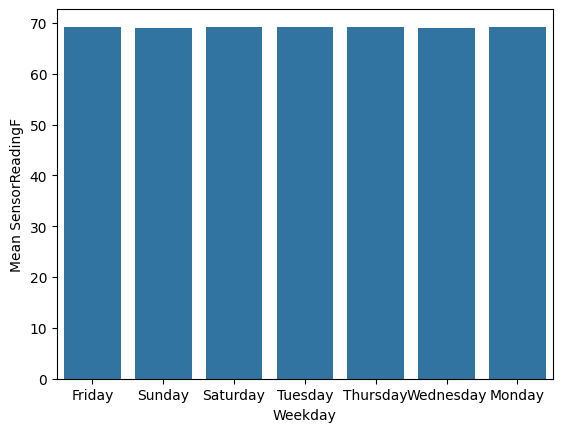

In [24]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week
""").df()

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

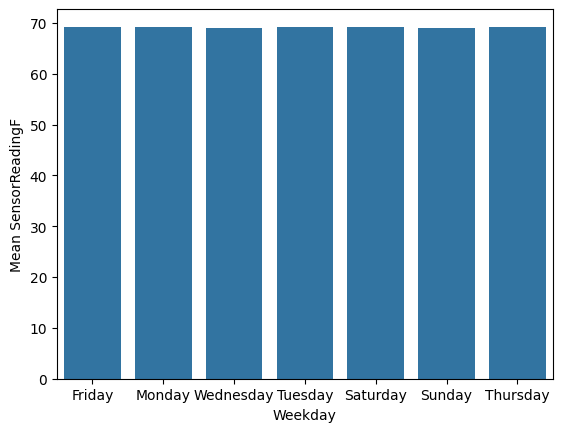

In [35]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week
""").df()

# need DISTINCT on utcs to prevent duplication.

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

In [30]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID_Coris) as 'Count of Devices'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('data/devices.parquet') AS d
        ON d.DeviceID_Coris = dr.DeviceID_Coris
    GROUP BY Building
    ORDER BY min(date)
""").df()

,Building,First Reading,Count of Devices
0,Kline Geology Laboratory,2023-11-15,9
1,,2024-06-20,4
2,Yale Peabody Museum,2024-07-16,22
3,Collection Studies Center (West Campus),2024-07-16,20
4,Environmental Science Center,2024-07-16,10
